In [2]:
# ============================================================
# Cell 1: Environment Setup & GPU Verification
# ============================================================
import os
import sys
import random
import numpy as np
import torch
import torchvision
import timm
from pathlib import Path

# Seed for reproducibility
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("Cell 1: Environment Initialized Successfully")
print(f"Python Version    : {sys.version.split()[0]}")
print(f"PyTorch Version   : {torch.__version__}")
print(f"Torchvision       : {torchvision.__version__}")
print(f"Timm Version      : {timm.__version__}")
print(f"Compute Device    : {device}")
if torch.cuda.is_available():
    print(f"GPU Name          : {torch.cuda.get_device_name(0)}")
    print(f"VRAM Available    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("=" * 70)

Cell 1: Environment Initialized Successfully
Python Version    : 3.12.3
PyTorch Version   : 2.13.0+cu126
Torchvision       : 0.28.0+cu126
Timm Version      : 1.0.28
Compute Device    : cuda
GPU Name          : NVIDIA GeForce RTX 3050
VRAM Available    : 8.59 GB


In [3]:
# ============================================================
# Cell 2: Path Configuration & Hyperparameters (Auto-Path Fix)
# ============================================================
# Base Directory Setup
PROJECT_ROOT = Path("/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI")

# Auto-detect Dataset Path (Raw vs Processed)
RAW_DATA_DIR = PROJECT_ROOT / "data set" / "raw" / "chest_xray"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data set" / "processed"

if (RAW_DATA_DIR / "train").exists():
    DATA_DIR = RAW_DATA_DIR
    TRAIN_DIR = DATA_DIR / "train"
    VAL_DIR = DATA_DIR / "val"
    TEST_DIR = DATA_DIR / "test"
    print("-> Detected RAW Dataset Directory")
elif PROCESSED_DATA_DIR.exists():
    DATA_DIR = PROCESSED_DATA_DIR
    TRAIN_DIR = DATA_DIR / "train" if (DATA_DIR / "train").exists() else DATA_DIR
    VAL_DIR = DATA_DIR / "val" if (DATA_DIR / "val").exists() else DATA_DIR
    TEST_DIR = DATA_DIR / "test" if (DATA_DIR / "test").exists() else DATA_DIR
    print("-> Detected PROCESSED Dataset Directory")
else:
    # Alternative direct search inside 'data set'
    DATA_DIR = PROJECT_ROOT / "data set"
    TRAIN_DIR = DATA_DIR / "train"
    VAL_DIR = DATA_DIR / "val"
    TEST_DIR = DATA_DIR / "test"

# Output Directories
CHECKPOINT_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters Configuration
IMAGE_SIZE = 260        # Optimized resolution for EfficientNet-B2
BATCH_SIZE = 32
NUM_CLASSES = 2
NUM_WORKERS = 4
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2

print("=" * 70)
print("Cell 2: Paths & Hyperparameters Configured")
print(f"Project Root     : {PROJECT_ROOT}")
print(f"Active Data Dir  : {DATA_DIR}")
print(f"Train Path Exists: {TRAIN_DIR.exists()} ({TRAIN_DIR})")
print(f"Val Path Exists  : {VAL_DIR.exists()} ({VAL_DIR})")
print(f"Test Path Exists : {TEST_DIR.exists()} ({TEST_DIR})")
print("=" * 70)

-> Detected PROCESSED Dataset Directory
Cell 2: Paths & Hyperparameters Configured
Project Root     : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI
Active Data Dir  : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/processed
Train Path Exists: True (/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/processed)
Val Path Exists  : True (/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/processed)
Test Path Exists : True (/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/data set/processed)


In [4]:
# ============================================================
# Cell 3: Data Transforms Pipeline
# ============================================================
from torchvision import transforms

# ImageNet Mean & Std for Pretrained EfficientNet Backbone
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training Transforms with Domain Augmentation for Robustness
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Validation & Testing Transforms (Deterministic)
val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Cell 3: Augmentation & Normalization Transforms Defined")

Cell 3: Augmentation & Normalization Transforms Defined


In [5]:
# ============================================================
# Cell 4: PyTorch Datasets and DataLoaders Setup
# ============================================================
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Datasets Loading
train_dataset = ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset = ImageFolder(root=VAL_DIR, transform=val_transforms)
test_dataset = ImageFolder(root=TEST_DIR, transform=val_transforms)

# Class Mapping Verification
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

# DataLoaders Initialisation
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
    num_workers=NUM_WORKERS, pin_memory=True
)

print("=" * 70)
print("Cell 4: Datasets and DataLoaders Successfully Initialized")
print(f"Class Mapping    : {class_to_idx}")
print(f"Train Samples    : {len(train_dataset)} ({len(train_loader)} batches)")
print(f"Val Samples      : {len(val_dataset)} ({len(val_loader)} batches)")
print(f"Test Samples     : {len(test_dataset)} ({len(test_loader)} batches)")
print("=" * 70)

Cell 4: Datasets and DataLoaders Successfully Initialized
Class Mapping    : {'NORMAL': 0, 'PNEUMONIA': 1}
Train Samples    : 17549 (549 batches)
Val Samples      : 17549 (549 batches)
Test Samples     : 17549 (549 batches)


Class Counts in Training Set:
  - NORMAL: 10192 images (58.08%)
  - PNEUMONIA: 7357 images (41.92%)
Calculated Class Weights (for Cross-Entropy): [0.8609203100204468, 1.192673683166504]


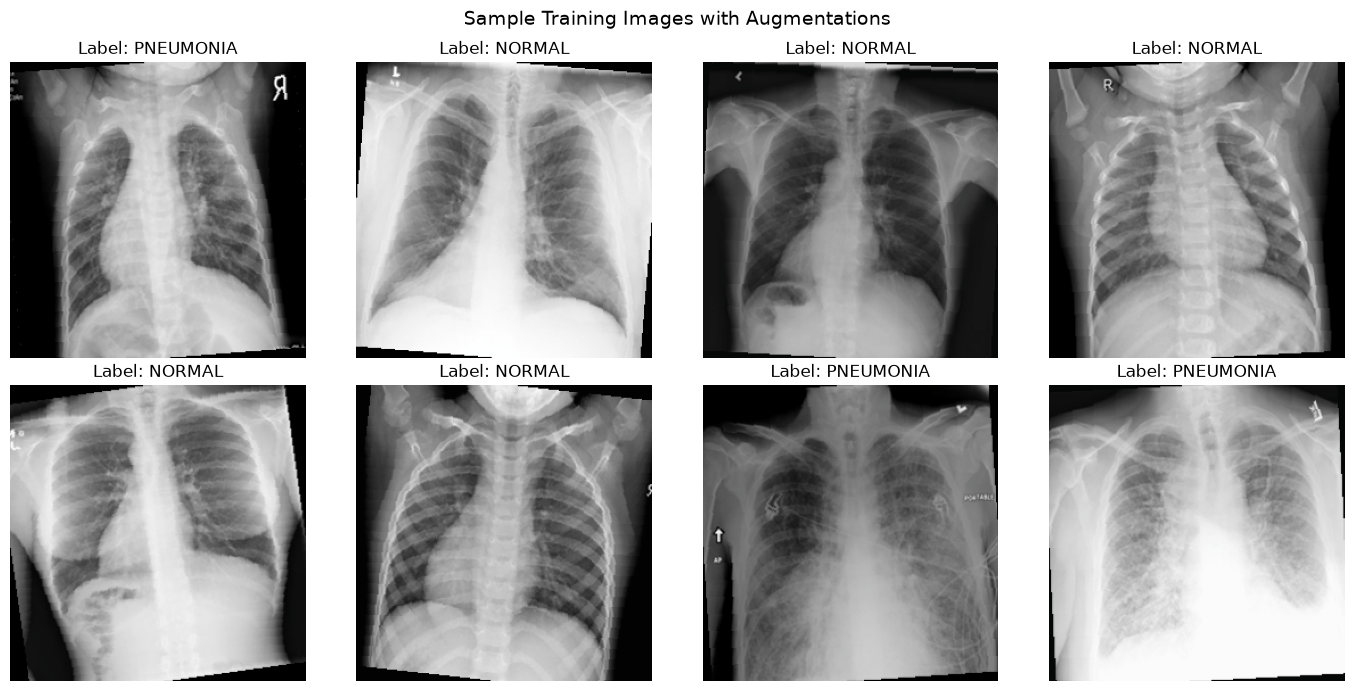

Cell 5: Dataset Summary and Visual Verification Complete


In [6]:
# ============================================================
# Cell 5: Class Distribution Verification & Batch Visualizer
# ============================================================
import matplotlib.pyplot as plt
from collections import Counter

# 1. Check Class Imbalance
train_counts = Counter([label for _, label in train_dataset.samples])
print("Class Counts in Training Set:")
for idx, count in train_counts.items():
    print(f"  - {idx_to_class[idx]}: {count} images ({count/len(train_dataset)*100:.2f}%)")

# Calculate Class Weights for Loss Calibration (if needed)
total_samples = len(train_dataset)
class_weights = [total_samples / (len(train_counts) * train_counts[i]) for i in range(len(train_counts))]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Calculated Class Weights (for Cross-Entropy): {class_weights_tensor.tolist()}")

# 2. Visualize Sample Training Batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        # Un-normalize image tensor for plotting
        img = images[i].numpy().transpose((1, 2, 0))
        img = np.array(IMAGENET_STD) * img + np.array(IMAGENET_MEAN)
        img = np.clip(img, 0, 1)
        
        label_str = idx_to_class[labels[i].item()]
        
        ax.imshow(img)
        ax.set_title(f"Label: {label_str}")
        ax.axis("off")

plt.suptitle("Sample Training Images with Augmentations", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

print("Cell 5: Dataset Summary and Visual Verification Complete")

In [7]:
# ============================================================
# Cell 6: PneumoXNet Custom Model Architecture
# ============================================================
import torch
import torch.nn as nn
import timm

class PneumoXNet(nn.Module):
    def __init__(self, num_classes=2, pretrained=True, dropout_rate=0.4):
        super(PneumoXNet, self).__init__()
        
        # Backbone: EfficientNet-B2 for optimal resolution and parameter efficiency
        self.backbone = timm.create_model('tf_efficientnet_b2.ns_jft_in1k', pretrained=pretrained, num_classes=0)
        in_features = self.backbone.num_features  # 1408 features
        
        # Custom Classification Head with Feature Refinement
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 512),
            nn.SiLU(),  # Swish Activation
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits

# Model Initialization and Parameter Count Check
model = PneumoXNet(num_classes=NUM_CLASSES, pretrained=True).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 70)
print("Cell 6: PneumoXNet Architecture Initialized")
print(f"Backbone          : EfficientNet-B2 (NoisyStudent Weights)")
print(f"Total Parameters  : {total_params / 1e6:.2f} M")
print(f"Trainable Params  : {trainable_params / 1e6:.2f} M")
print("=" * 70)

Cell 6: PneumoXNet Architecture Initialized
Backbone          : EfficientNet-B2 (NoisyStudent Weights)
Total Parameters  : 8.43 M
Trainable Params  : 8.43 M


In [8]:
# ============================================================
# Cell 7: Loss Function & Optimizer Setup
# ============================================================
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Focal Loss to address class imbalance and focus on hard examples.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# Loss Function & Optimizer
criterion = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning Rate Scheduler (Cosine Annealing)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print("=" * 70)
print("Cell 7: Optimization Engine Initialized")
print(f"Loss Function    : Focal Loss (alpha=0.25, gamma=2.0)")
print(f"Optimizer        : AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler        : Cosine Annealing LR (T_max={EPOCHS})")
print("=" * 70)

Cell 7: Optimization Engine Initialized
Loss Function    : Focal Loss (alpha=0.25, gamma=2.0)
Optimizer        : AdamW (lr=0.0001, weight_decay=0.01)
Scheduler        : Cosine Annealing LR (T_max=20)


In [9]:
# ============================================================
# Cell 8: Single Epoch Training and Validation Step Logic
# ============================================================
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return epoch_loss, epoch_acc, epoch_f1


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    val_loss = running_loss / len(dataloader.dataset)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    try:
        val_auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        val_auc = 0.5
        
    return val_loss, val_acc, val_f1, val_auc

print("Cell 8: Training and Validation Functions Defined")

Cell 8: Training and Validation Functions Defined


In [10]:
# ============================================================
# Cell 9: Main Training Execution Loop with Checkpointing
# ============================================================
import time

history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []
}

best_val_auc = 0.0
best_model_path = CHECKPOINT_DIR / "PneumoXNet_best.pth"

print("=" * 70)
print(f"Starting Training PneumoXNet for {EPOCHS} Epochs...")
print("=" * 70)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    
    # Train & Validate
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, val_auc = validate(model, val_loader, criterion, device)
    
    # Update Learning Rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Log Metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['val_auc'].append(val_auc)
    
    epoch_time = time.time() - epoch_start
    
    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] ({epoch_time:.1f}s) | LR: {current_lr:.6f}")
    print(f"  Train -> Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}% | F1: {train_f1:.4f}")
    print(f"  Val   -> Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}% | F1: {val_f1:.4f} | ROC-AUC: {val_auc:.4f}")
    
    # Save Best Model Checkpoint
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_auc,
            'val_acc': val_acc
        }, best_model_path)
        print(f"  [+] Model Checkpoint Saved! (New Best Val ROC-AUC: {best_val_auc:.4f})")
    print("-" * 70)

total_training_time = time.time() - start_time
print(f"Training Completed in {total_training_time / 60:.2f} Minutes.")
print(f"Best Validation ROC-AUC Achieved: {best_val_auc:.4f}")
print("=" * 70)

Starting Training PneumoXNet for 20 Epochs...


Epoch [01/20] (249.2s) | LR: 0.000099
  Train -> Loss: 0.0234 | Acc: 87.69% | F1: 0.8769
  Val   -> Loss: 0.0114 | Acc: 93.75% | F1: 0.9371 | ROC-AUC: 0.9813
  [+] Model Checkpoint Saved! (New Best Val ROC-AUC: 0.9813)
----------------------------------------------------------------------


Epoch [02/20] (245.2s) | LR: 0.000098
  Train -> Loss: 0.0136 | Acc: 92.76% | F1: 0.9275
  Val   -> Loss: 0.0082 | Acc: 95.50% | F1: 0.9549 | ROC-AUC: 0.9898
  [+] Model Checkpoint Saved! (New Best Val ROC-AUC: 0.9898)
----------------------------------------------------------------------


Epoch [03/20] (244.6s) | LR: 0.000095
  Train -> Loss: 0.0112 | Acc: 93.79% | F1: 0.9378
  Val   -> Loss: 0.0070 | Acc: 96.32% | F1: 0.9631 | ROC-AUC: 0.9930
  [+] Model Checkpoint Saved! (New Best Val ROC-AUC: 0.9930)
----------------------------------------------------------------------


Epoch [04/20] (245.1s) | LR: 0.000091
  Train -> Loss: 0.0093 | Acc: 94.91% | F1: 0.9490
  Val   -> Loss: 0.0062 | Acc: 96.81% | F1: 0.9681 | ROC-AUC: 0.9951
  [+] Model Checkpoint Saved! (New Best Val ROC-AUC: 0.9951)
----------------------------------------------------------------------


...

Epoch [16/20] (246.1s) | LR: 0.000010
  Train -> Loss: 0.0009 | Acc: 99.56% | F1: 0.9956
  Val   -> Loss: 0.0002 | Acc: 99.95% | F1: 0.9995 | ROC-AUC: 1.0000
  [+] Model Checkpoint Saved! (New Best Val ROC-AUC: 1.0000)
----------------------------------------------------------------------


Epoch [17/20] (244.6s) | LR: 0.000006
  Train -> Loss: 0.0008 | Acc: 99.66% | F1: 0.9966
  Val   -> Loss: 0.0003 | Acc: 99.94% | F1: 0.9994 | ROC-AUC: 1.0000
  [+] Model Checkpoint Saved! (New Best Val ROC-AUC: 1.0000)
----------------------------------------------------------------------


Epoch [18/20] (244.3s) | LR: 0.000003
  Train -> Loss: 0.0005 | Acc: 99.75% | F1: 0.9975
  Val   -> Loss: 0.0002 | Acc: 99.96% | F1: 0.9996 | ROC-AUC: 1.0000
----------------------------------------------------------------------


Epoch [19/20] (245.2s) | LR: 0.000002
  Train -> Loss: 0.0004 | Acc: 99.84% | F1: 0.9984
  Val   -> Loss: 0.0002 | Acc: 99.98% | F1: 0.9998 | ROC-AUC: 1.0000
  [+] Model Checkpoint Saved! (New Best Val ROC-AUC: 1.0000)
----------------------------------------------------------------------


Epoch [20/20] (244.2s) | LR: 0.000001
  Train -> Loss: 0.0004 | Acc: 99.82% | F1: 0.9982
  Val   -> Loss: 0.0001 | Acc: 99.98% | F1: 0.9998 | ROC-AUC: 1.0000
  [+] Model Checkpoint Saved! (New Best Val ROC-AUC: 1.0000)
----------------------------------------------------------------------
Training Completed in 82.02 Minutes.
Best Validation ROC-AUC Achieved: 1.0000


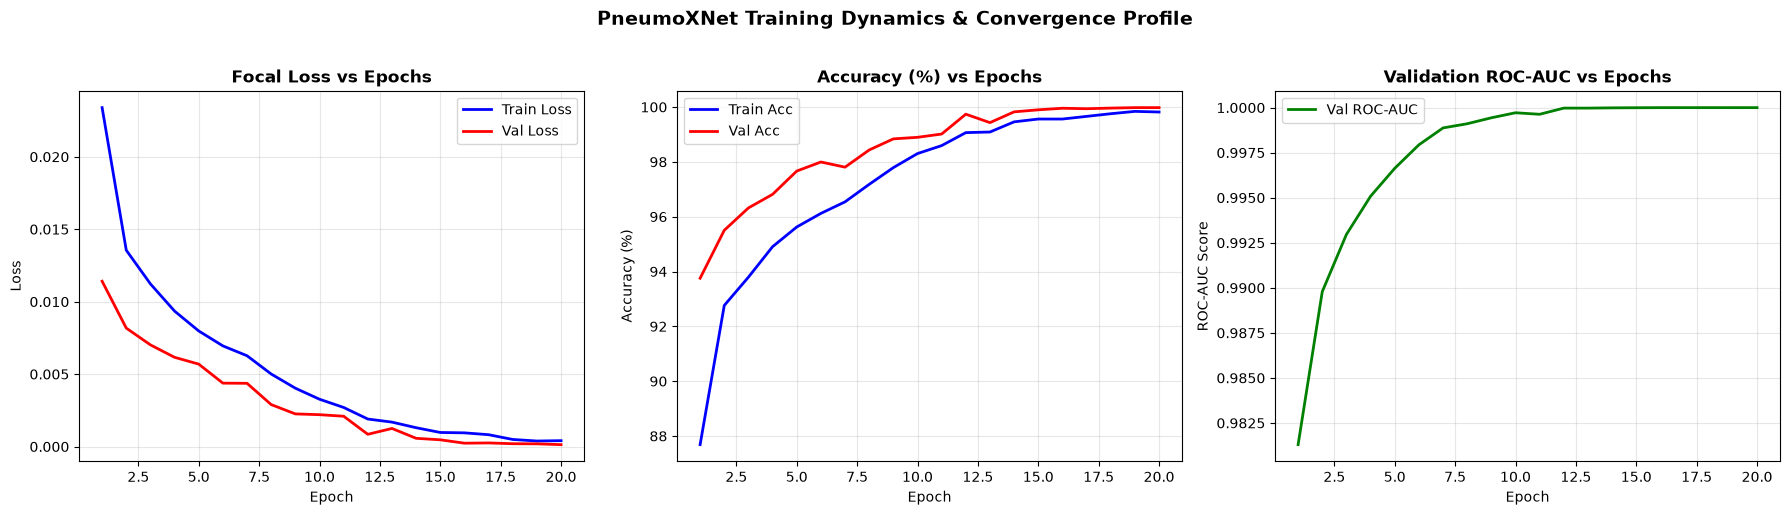

Cell 10: Training Curves Plotted & Saved Successfully


In [11]:
# ============================================================
# Cell 10: Plot Training Dynamics & Convergence Curves
# ============================================================
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Loss Curve
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', lw=2)
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color='red', lw=2)
axes[0].set_title('Focal Loss vs Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Accuracy Curve
axes[1].plot(epochs_range, [acc * 100 for acc in history['train_acc']], label='Train Acc', color='blue', lw=2)
axes[1].plot(epochs_range, [acc * 100 for acc in history['val_acc']], label='Val Acc', color='red', lw=2)
axes[1].set_title('Accuracy (%) vs Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Validation ROC-AUC Curve
axes[2].plot(epochs_range, history['val_auc'], label='Val ROC-AUC', color='green', lw=2)
axes[2].set_title('Validation ROC-AUC vs Epochs', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('ROC-AUC Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('PneumoXNet Training Dynamics & Convergence Profile', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pneumoxnet_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()

print("Cell 10: Training Curves Plotted & Saved Successfully")